In [6]:
import os
import random

import torch
import numpy as np
import matplotlib.pyplot as plt

from transformers import AutoTokenizer, AutoModelForSequenceClassification
from datasets import load_dataset
from sklearn.metrics.pairwise import cosine_similarity
from tqdm import tqdm

###############################################################################
# 1) Define Arguments (hard-coded for Jupyter)
###############################################################################
args = {
    "model_name": "nlpaueb/sec-bert-base",
    "wiki_dataset_name": "wikitext",
    "wiki_dataset_config": "wikitext-2-raw-v1",
    "wiki_split": "train",
    "financial_dataset_name": "financial_phrasebank",
    "financial_dataset_config": "sentences_50agree",
    "financial_split": "train",
    "max_texts": 30000,
    "batch_size": 64,
    "drift_threshold_std": 4.0,
    "window_size": 50,
    "variance_threshold": 0.0001,
    "output_dir": "results_jupyter",
}

###############################################################################
# 2) Utility Functions
###############################################################################
def batch_generator(data, batch_size=32):
    """Generate batches from a list of data."""
    for i in range(0, len(data), batch_size):
        yield data[i : i + batch_size]

def extract_cls_embeddings(model, tokenizer, texts, device):
    """
    Tokenize and extract [CLS] embeddings from a batch of texts
    using a HuggingFace Transformer model.
    """
    encodings = tokenizer(
        texts,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=512
    )
    input_ids = encodings["input_ids"].to(device)
    attention_mask = encodings["attention_mask"].to(device)

    with torch.no_grad():
        # For AutoModelForSequenceClassification,
        # we usually access the underlying base model: model.bert(...)
        outputs = model.bert(input_ids, attention_mask=attention_mask)
        cls_embeddings = outputs.last_hidden_state[:, 0, :]  # [batch_size, hidden_dim]
    return cls_embeddings.cpu().numpy()

def cluster_drift_indices(
    drift_indices,
    distance_threshold=128,
    ignore_solo_outliers=False,
    min_cluster_size=2
):
    """
    Post-process a list of integer drift indices by grouping those
    that are within `distance_threshold` of each other. Optionally
    ignore clusters that are too small.
    """
    if not drift_indices:
        return []

    # Sort the drift indices
    drift_indices = sorted(drift_indices)
    clusters = []
    current_cluster = [drift_indices[0]]

    for i in range(1, len(drift_indices)):
        if drift_indices[i] - drift_indices[i - 1] <= distance_threshold:
            current_cluster.append(drift_indices[i])
        else:
            clusters.append(current_cluster)
            current_cluster = [drift_indices[i]]
    clusters.append(current_cluster)

    # If ignoring solo outliers, remove clusters smaller than min_cluster_size
    if ignore_solo_outliers:
        clusters = [c for c in clusters if len(c) >= min_cluster_size]

    return clusters

def choose_cluster_representatives(clusters, mode="first"):
    """
    Pick a single integer "representative" from each cluster of drift indices.
    mode can be 'first', 'last', 'mean', or 'median'.
    """
    representatives = []
    for cluster in clusters:
        if mode == "first":
            representatives.append(cluster[0])
        elif mode == "last":
            representatives.append(cluster[-1])
        elif mode == "mean":
            representatives.append(int(sum(cluster) / len(cluster)))
        elif mode == "median":
            mid = len(cluster) // 2
            sorted_cluster = sorted(cluster)
            if len(cluster) % 2 == 1:
                representatives.append(sorted_cluster[mid])
            else:
                lower = sorted_cluster[mid - 1]
                upper = sorted_cluster[mid]
                representatives.append(int((lower + upper) / 2))
        else:
            raise ValueError(f"Unknown mode: {mode}")
    return representatives

###############################################################################
# 3) DriftDetector Class
###############################################################################
class DriftDetector:
    """
    Simple drift detector that:
    1) Initializes a prototype embedding vector from a baseline set.
    2) Batches through data, computes average [CLS] embedding for each batch.
    3) Compares new batch embedding to the prototype with cosine similarity.
    4) If similarity < threshold, or the variance is too low, mark a drift.
    5) Dynamically update the prototype after each batch.
    """
    def __init__(self, model, tokenizer, device, batch_generator, args):
        self.model = model
        self.tokenizer = tokenizer
        self.device = device
        self.batch_generator = batch_generator
        self.args = args

        self.prototype = None
        self.prototypes = []
        self.drifts = []         # List of integer indices
        self.cosine_scores = []

    def initialize_baseline(self, texts):
        """Compute an initial prototype from a set of texts."""
        print("Initializing baseline prototype...")
        embeddings = []
        for batch in self.batch_generator(texts[: self.args['max_texts']], self.args['batch_size']):
            cls_emb = extract_cls_embeddings(self.model, self.tokenizer, batch, self.device)
            embeddings.append(cls_emb)
        all_embeddings = np.concatenate(embeddings, axis=0)
        self.prototype = np.mean(all_embeddings, axis=0)
        self.prototypes.append(self.prototype)
        print("Baseline prototype initialized.")

    def detect_drifts(self, texts):
        """Go through the data in batches to detect potential drifts."""
        print("Detecting drifts...")
        for i, batch in enumerate(tqdm(self.batch_generator(texts, self.args['batch_size']))):
            batch_embeddings = extract_cls_embeddings(self.model, self.tokenizer, batch, self.device)

            # Mean embedding for current batch
            mean_emb = batch_embeddings.mean(axis=0, keepdims=True)
            sim = cosine_similarity(mean_emb, [self.prototype])[0][0]
            self.cosine_scores.append(sim)

            # If we have enough scores, check for drift
            if len(self.cosine_scores) >= self.args['window_size']:
                threshold = self._calculate_threshold()
                variance = self._calculate_variance()
                if sim < threshold or (variance is not None and variance < self.args['variance_threshold']):
                    # The drift index is the data index, not the batch number
                    drift_index = i * self.args['batch_size']
                    self.drifts.append(drift_index)
                    print(f"  Drift detected at index={drift_index} (batch={i}), similarity={sim:.4f}")

            # Update the prototype
            self._update_prototype(batch_embeddings)

    def _calculate_threshold(self):
        """Use rolling mean and std to define a drift threshold."""
        recent_scores = self.cosine_scores[-self.args['window_size']:]
        mean_val = np.mean(recent_scores)
        std_val = np.std(recent_scores)
        threshold = mean_val - (self.args['drift_threshold_std'] * std_val)
        return threshold

    def _calculate_variance(self):
        """Variance of the most recent cosine similarity window."""
        if len(self.cosine_scores) < self.args['window_size']:
            return None
        recent_scores = self.cosine_scores[-self.args['window_size']:]
        return np.var(recent_scores)

    def _update_prototype(self, batch_embeddings):
        """Update the prototype by combining current prototype with new embeddings."""
        delta = batch_embeddings - self.prototype
        # Weighted update: closer embeddings to the prototype get more weight
        distances = np.linalg.norm(delta, axis=1)
        weights = np.exp(-distances / 2.0)
        weighted_sum = np.sum(weights[:, None] * delta, axis=0)
        self.prototype += weighted_sum / np.sum(weights)
        self.prototypes.append(self.prototype)

###############################################################################
# 4) Main "Notebook" Flow
###############################################################################

# ------------------------
# 4a) Device Setup
# ------------------------
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
print("Using device:", device)

# Create output dir
os.makedirs(args["output_dir"], exist_ok=True)

# ------------------------
# 4b) Load Model & Tokenizer
# ------------------------
print("Loading model and tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(args["model_name"])
model = AutoModelForSequenceClassification.from_pretrained(args["model_name"])
model.to(device)
model.eval()

# ------------------------
# 4c) Load Original (WikiText) Dataset
# ------------------------
print("Loading original WikiText dataset...")
wiki_dataset = load_dataset(
    args["wiki_dataset_name"],
    args["wiki_dataset_config"],
    split=args["wiki_split"]
)
texts = wiki_dataset["text"]
if args["max_texts"] > 0 and args["max_texts"] < len(texts):
    texts = texts[: args["max_texts"]]
print(f"Loaded {len(texts)} WikiText samples")

# ------------------------
# 4d) Load Financial Dataset
# ------------------------
print("Loading financial dataset...")
fin_dataset = load_dataset(
    args["financial_dataset_name"],
    args["financial_dataset_config"],
    split=args["financial_split"]
)
financial_texts = fin_dataset["sentence"]
random.shuffle(financial_texts)

# Simulate Kaggle-like data from the first 1K finance texts
kaggle_texts = financial_texts[:1000]
print(f"Loaded {len(financial_texts)} finance samples; {len(kaggle_texts)} Kaggle-like samples")

# ------------------------
# 4e) Simulate domain drifts
# ------------------------
n = len(texts)
drift_start_1, drift_end_1 = n // 3, n // 2
drift_start_2, drift_end_2 = 2 * n // 3, 5 * n // 6

fin_idx = 0
for i in range(drift_start_1, drift_end_1):
    texts[i] = financial_texts[fin_idx % len(financial_texts)]
    fin_idx += 1

kaggle_idx = 0
for i in range(drift_start_2, drift_end_2):
    texts[i] = kaggle_texts[kaggle_idx % len(kaggle_texts)]
    kaggle_idx += 1

print("Simulated domain drifts:")
print(f"  Drift region 1: indices [{drift_start_1}, {drift_end_1}) (Finance)")
print(f"  Drift region 2: indices [{drift_start_2}, {drift_end_2}) (Kaggle)")

# ------------------------
# 4f) Initialize Detector
# ------------------------
detector = DriftDetector(
    model=model,
    tokenizer=tokenizer,
    device=device,
    batch_generator=batch_generator,
    args=args
)
detector.initialize_baseline(texts)
detector.detect_drifts(texts)



Using device: mps
Loading model and tokenizer...


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at nlpaueb/sec-bert-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Loading original WikiText dataset...
Loaded 30000 WikiText samples
Loading financial dataset...
Loaded 4846 finance samples; 1000 Kaggle-like samples
Simulated domain drifts:
  Drift region 1: indices [10000, 15000) (Finance)
  Drift region 2: indices [20000, 25000) (Kaggle)
Initializing baseline prototype...
Baseline prototype initialized.
Detecting drifts...


91it [02:32,  1.51s/it]

  Drift detected at index=5760 (batch=90), similarity=0.8805


...

396it [07:17,  1.29s/it]

  Drift detected at index=25280 (batch=395), similarity=0.9529


397it [07:20,  1.79s/it]

  Drift detected at index=25344 (batch=396), similarity=0.9412


469it [09:30,  1.22s/it]



Raw drift indices: [5760, 13248, 13312, 13376, 13440, 13504, 13568, 13632, 13696, 13760, 13824, 13888, 13952, 14016, 14080, 14144, 14208, 14272, 14336, 14400, 14464, 14528, 14592, 14656, 14720, 14784, 14848, 14912, 14976, 15040, 15104, 15168, 15232, 15296, 23232, 23296, 23360, 23424, 23488, 23552, 23616, 23680, 23744, 23808, 23872, 23936, 24000, 24064, 24128, 24192, 24256, 24320, 24384, 24448, 24512, 24576, 24640, 24704, 24768, 24832, 24896, 24960, 25024, 25088, 25152, 25216, 25280, 25344]
Clustered drift indices: [[13248, 13312, 13376, 13440, 13504, 13568, 13632, 13696, 13760, 13824, 13888, 13952, 14016, 14080, 14144, 14208, 14272, 14336, 14400, 14464, 14528, 14592, 14656, 14720, 14784, 14848, 14912, 14976, 15040, 15104, 15168, 15232, 15296], [23232, 23296, 23360, 23424, 23488, 23552, 23616, 23680, 23744, 23808, 23872, 23936, 24000, 24064, 24128, 24192, 24256, 24320, 24384, 24448, 24512, 24576, 24640, 24704, 24768, 24832, 24896, 24960, 25024, 25088, 25152, 25216, 25280, 25344]]
Clust

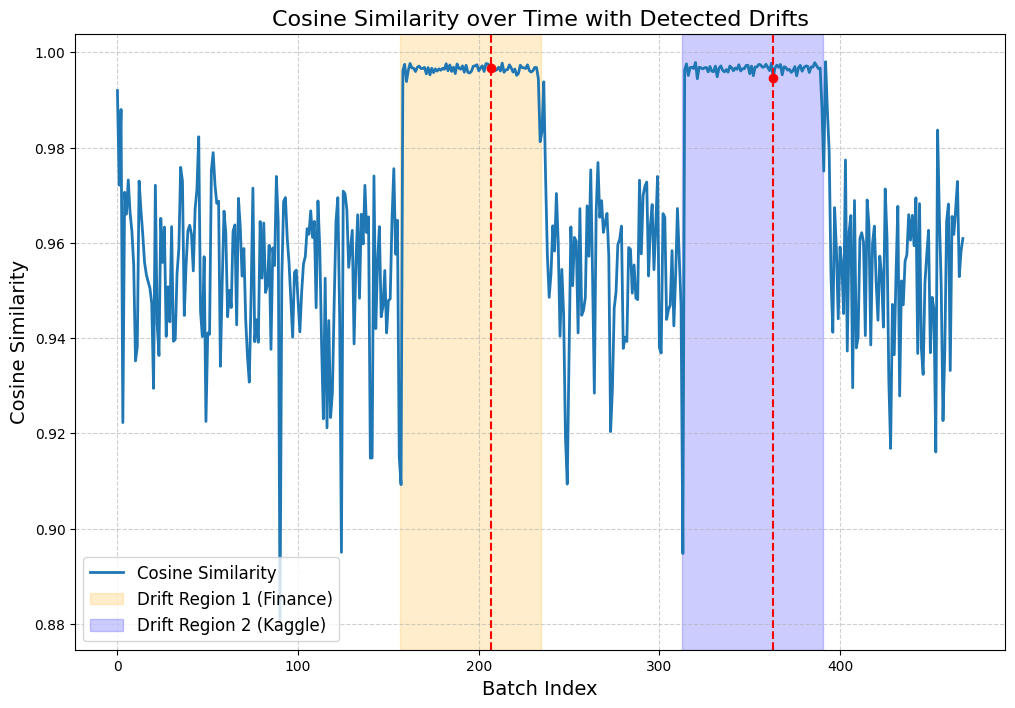


Plot saved to: results_jupyter/drift_detection_plot.png


In [8]:
# ------------------------
# 4g) Post-process drifts via clustering
# ------------------------
drift_clusters = cluster_drift_indices(
    drift_indices=detector.drifts,
    distance_threshold=128,
    ignore_solo_outliers=True,
    min_cluster_size=4
)
drift_reps = choose_cluster_representatives(drift_clusters, mode="first")

print("\nRaw drift indices:", detector.drifts)
print("Clustered drift indices:", drift_clusters)
print("Cluster representatives:", drift_reps)

# ------------------------
# 4h) Plot Results
# ------------------------
plt.figure(figsize=(12, 8))
plt.plot(detector.cosine_scores, label="Cosine Similarity", linewidth=2)

# Mark known drift regions
plt.axvspan(drift_start_1 / args["batch_size"], drift_end_1 / args["batch_size"],
            color="orange", alpha=0.2, label="Drift Region 1 (Finance)")
plt.axvspan(drift_start_2 / args["batch_size"], drift_end_2 / args["batch_size"],
            color="blue", alpha=0.2, label="Drift Region 2 (Kaggle)")

# Show cluster representatives
for rep in drift_reps:
    batch_x = rep / args["batch_size"]
    if 0 <= batch_x < len(detector.cosine_scores):
        plt.axvline(batch_x, color="red", linestyle="--")
        plt.scatter(batch_x, detector.cosine_scores[int(batch_x)], color="red", zorder=5)

plt.title("Cosine Similarity over Time with Detected Drifts", fontsize=16)
plt.xlabel("Batch Index", fontsize=14)
plt.ylabel("Cosine Similarity", fontsize=14)
plt.legend(loc="best", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)
save_path = os.path.join(args["output_dir"], "drift_detection_plot.png")
plt.savefig(save_path)
plt.show()

print(f"\nPlot saved to: {save_path}")
